In [ ]:
#Import common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.style.use('ggplot')

**Data Importation and Preliminary Exploration**

In [ ]:
#Import the data set
df = pd.read_csv('eastville.csv')
#Show number of rows and columns
print(f"Total rows: {len(df)}")
print(f"Total columns:{len(df.columns)}")
print(f"\nDataset preview:")
df.head()

Total rows: 108
Total columns:12

Dataset preview:


,house,sqft,beds,baths,heat,style,garage,basement,age,fire,price,school
0,1,1610,3,2,0,Cape Cod,1,1,12,1,234280,Apple Valley
1,2,2151,3,2,1,Cape Cod,2,0,13,1,246360,Plum Ridge
2,3,1718,4,2,0,Cape Cod,2,1,17,0,265650,Plum Ridge
3,4,1534,3,2,0,Cape Cod,2,1,11,1,237420,Plum Ridge
4,5,1527,3,2,0,Cape Cod,1,0,6,1,259170,Plum Ridge


In [ ]:
# Show the types of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   house     108 non-null    int64 
 1   sqft      108 non-null    int64 
 2   beds      108 non-null    int64 
 3   baths     108 non-null    int64 
 4   heat      108 non-null    int64 
 5   style     108 non-null    object
 6   garage    108 non-null    int64 
 7   basement  108 non-null    int64 
 8   age       108 non-null    int64 
 9   fire      108 non-null    int64 
 10  price     108 non-null    int64 
 11  school    108 non-null    object
dtypes: int64(10), object(2)
memory usage: 10.3+ KB


**Conclusion:**
The dataset contains 108 rows and 12 columns.There are 108 homes, each with 12 attributes.
There are 10 numeric variables and 2 categorical variables (style, school). No missing data were found.

**Single Variable Analysis:**

**1.Price**

In [ ]:
# Numerical summary
print("=== Numerical Summary for Price ===")
print(df['price'].describe().round(2))

=== Numerical Summary for Price ===
count       108.00
mean     341394.63
std       82092.91
min      197300.00
25%      285017.50
50%      331715.00
75%      377335.00
max      675030.00
Name: price, dtype: float64


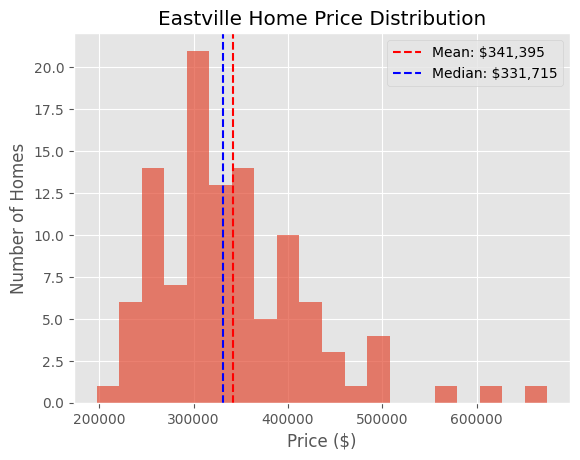

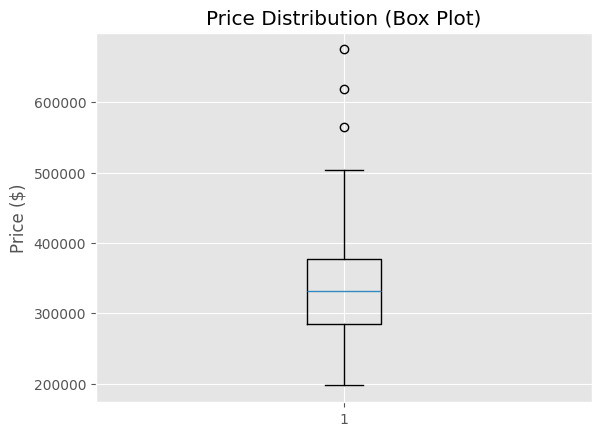

In [ ]:
# Graphical presentations

# Describe price numerically
price_stats = df['price'].describe()
# Access the stats for mean
price_stats.round(0)
#Create a histogram for price
plt.hist(df['price'], bins=20, alpha=0.7)
# Add the mean line on the plot
plt.axvline(df['price'].mean(), color='red', linestyle='--',
            label=f'Mean: ${df["price"].mean():,.0f}')

plt.axvline(price_stats['50%'], color='blue', linestyle='--',
            label=f'Median: ${price_stats["50%"]:,.0f}')
plt.xlabel('Price ($)')
plt.ylabel('Number of Homes')
plt.title('Eastville Home Price Distribution')
plt.legend()
plt.show()

# Create a box plot for price
plt.boxplot(df['price'])
plt.ylabel('Price ($)')
plt.title('Price Distribution (Box Plot)')
plt.show()


**Conclusion**: the average home price in Eastville is approximately **\$341,395**, with the median of **\$331,715**.  
Overall, prices cluster between **\$300,000** and **\$400,000**.


**2.Style**


=== Frequency Summary for Style ===
style
Ranch        44
Cape Cod     39
Two-story    25
Name: count, dtype: int64

=== Percentage by Style ===
style
Ranch        40.74
Cape Cod     36.11
Two-story    23.15
Name: proportion, dtype: float64


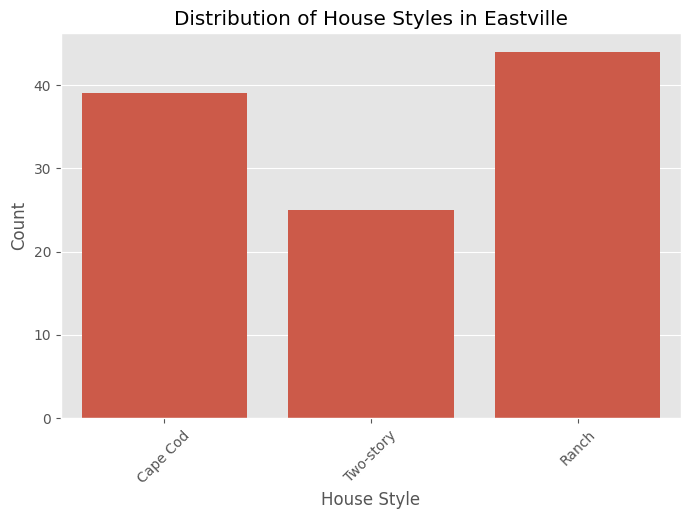

In [ ]:
#Frequency summary
print("=== Frequency Summary for Style ===")
style_counts = df['style'].value_counts()
print(style_counts)

#Relative frequency (percentage)
print("\n=== Percentage by Style ===")
style_percent = (df['style'].value_counts(normalize=True) * 100).round(2)
print(style_percent)

#Bar chart of house styles
plt.figure(figsize=(8, 5))
sns.countplot(x='style', data=df)
plt.title('Distribution of House Styles in Eastville')
plt.xlabel('House Style')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**Conclusion**:ranch-style homes are the most common, followed by Cape Cod and Two-story homes. Ranch and Cape Cod together make up over three-quarters of all houses.

**Two Variable Analysis**

**1.Price and style**

In [ ]:
# Mean and standard deviation of price by style (rounded)
price_stats = df.groupby('style')['price'].agg(['count', 'mean', 'std', 'median']).round(2)
print("=== Price by Style ===")
print(price_stats)


=== Price by Style ===
           count       mean       std    median
style                                          
Cape Cod      39  305173.85  71785.66  293220.0
Ranch         44  389675.45  78797.25  381080.0
Two-story     25  312924.80  59265.06  313940.0


[305173.85 389675.45 312924.8 ] Index(['Cape Cod', 'Ranch', 'Two-story'], dtype='object', name='style')


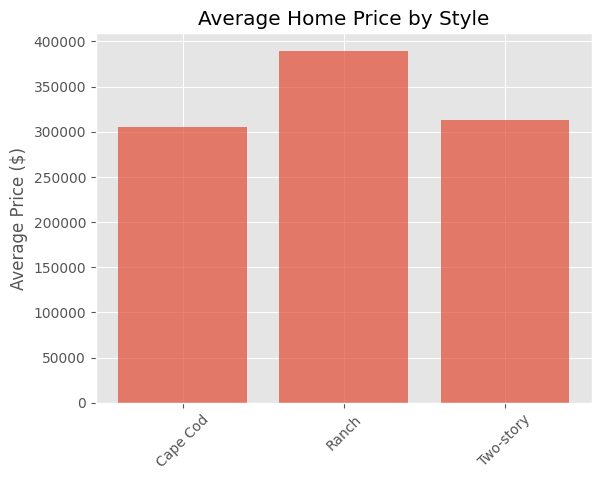

In [ ]:
# Create a bar chart
style_stats = df.groupby('style')['price'].agg(['mean', 'std', 'count']).round(2)
style_means = style_stats['mean'].values
style_names = style_stats.index
print(style_means, style_names)

plt.bar(style_names, style_means, alpha=0.7)
plt.ylabel('Average Price ($)', fontsize=12)
plt.title('Average Home Price by Style')
plt.xticks(rotation=45)
plt.show()


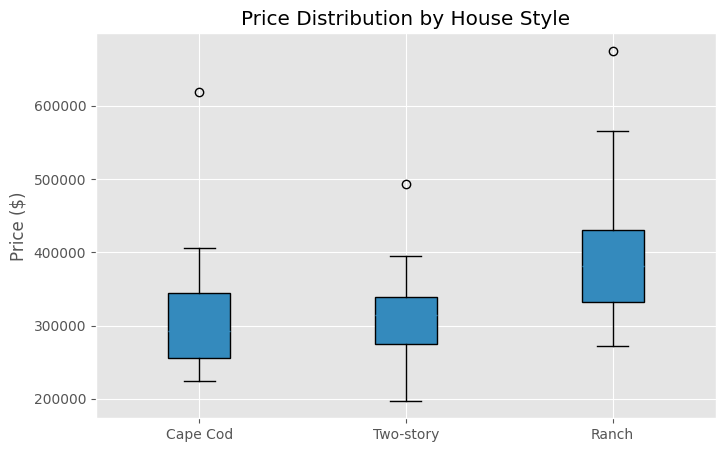

In [ ]:
#Create a box plot for prices by all styles
style_names = df['style'].unique()
style_data = [df[df['style'] == s]['price'] for s in style_names]

plt.figure(figsize=(8, 5))
plt.boxplot(style_data, tick_labels=style_names, patch_artist=True)
plt.ylabel('Price ($)')
plt.title('Price Distribution by House Style')
plt.show()


/tmp/ipython-input-1873470598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


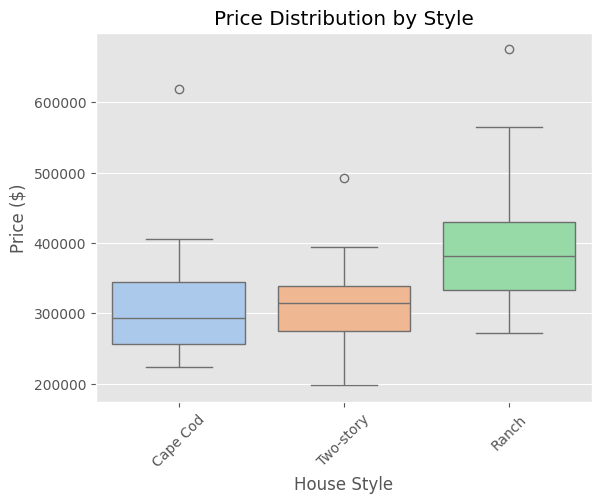

In [ ]:
#Create the boxplot with seaborn (statistical)
sns.boxplot(
    data=df,
    x='style',
    y='price',
    palette='pastel'
)
plt.title('Price Distribution by Style')
plt.xlabel('House Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Statistical significance

def test_statistical_significance(group1, group2, alpha=0.05):
    # Perform independent samples t-test
    t_stat, p_value = stats.ttest_ind(group1, group2)

    print(f"📊 TEST RESULTS: t-statistic = {t_stat:.3f},  p-value = {p_value:.4f}")

    return p_value

#Create price groups for each style
cape_cod_prices = df[df['style'] == 'Cape Cod']['price']
ranch_prices = df[df['style'] == 'Ranch']['price']
two_story_prices = df[df['style'] == 'Two-story']['price']

#Cape Cod vs Ranch
print("Cape Cod vs Ranch")
p1 = test_statistical_significance(cape_cod_prices, ranch_prices)

#Cape Cod vs Two-story
print("Cape Cod vs Two-story")
p2 = test_statistical_significance(cape_cod_prices, two_story_prices)

#Ranch vs Two-story
print("Ranch vs Two-story")
p3 = test_statistical_significance(ranch_prices, two_story_prices)


Cape Cod vs Ranch
📊 TEST RESULTS: t-statistic = -5.083,  p-value = 0.0000
Cape Cod vs Two-story
📊 TEST RESULTS: t-statistic = -0.450,  p-value = 0.6542
Ranch vs Two-story
📊 TEST RESULTS: t-statistic = 4.232,  p-value = 0.0001


In [ ]:
#Practical significance

#Define a function to calculate the effect size (Cohen's d)
def calculate_effect_size(group1, group2):
    # Calculate means
    group1_mean = group1.mean()
    group2_mean = group2.mean()

    # Calculate Cohen's d
    pooled_std = np.sqrt(
        ((len(group1)-1) * group1.std()**2 +
         (len(group2)-1) * group2.std()**2) /
        (len(group1) + len(group2) - 2)
    )

    cohens_d = (group1_mean - group2_mean) / pooled_std

    print(f"📊 EFFECT SIZE (Cohen's d): {cohens_d:.3f}")
    return cohens_d

# Calculate effect sizes between all style pairs
print("Cape Cod vs Ranch")
d1 = calculate_effect_size(cape_cod_prices, ranch_prices)

print("Cape Cod vs Two-story")
d2 = calculate_effect_size(cape_cod_prices, two_story_prices)

print("Ranch vs Two-story")
d3 = calculate_effect_size(ranch_prices, two_story_prices)



Cape Cod vs Ranch
📊 EFFECT SIZE (Cohen's d): -1.118
Cape Cod vs Two-story
📊 EFFECT SIZE (Cohen's d): -0.115
Ranch vs Two-story
📊 EFFECT SIZE (Cohen's d): 1.060


**Conclusion**: Ranch-style homes have significantly higher prices compared to Cape Cod and Two-story homes, suggesting a large practical difference. Prices between Cape Cod and Two-story homes show no significant difference (p = 0.65, d = -0.115). These results indicate that house style has a meaningful impact on home price, with Ranch homes commanding the highest market value.

**2.Sqft and price**

In [ ]:
# Calculate price per square foot
df['price_per_sqft'] = (df['price'] / df['sqft']).round(2)
# Descriptive statistics
price_per_sqft_stats = df['price_per_sqft'].describe().round(2)
print(price_per_sqft_stats)

mean_psf = price_per_sqft_stats['mean']
median_psf = price_per_sqft_stats['50%']
std_psf = price_per_sqft_stats['std']

print(f"\n💰 KEY METRICS:")
print(f"   Mean $/sqft:   ${mean_psf:.2f}")
print(f"   Median $/sqft: ${median_psf:.2f}")
print(f"   Std Dev:       ${std_psf:.2f}")

count    108.00
mean     173.52
std       28.27
min      114.37
25%      155.85
50%      171.54
75%      190.61
max      255.60
Name: price_per_sqft, dtype: float64

💰 KEY METRICS:
   Mean $/sqft:   $173.52
   Median $/sqft: $171.54
   Std Dev:       $28.27


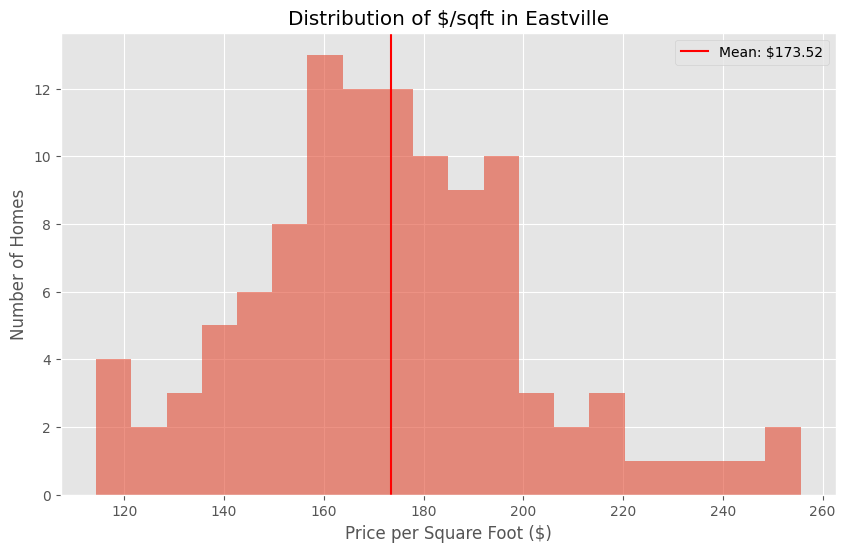

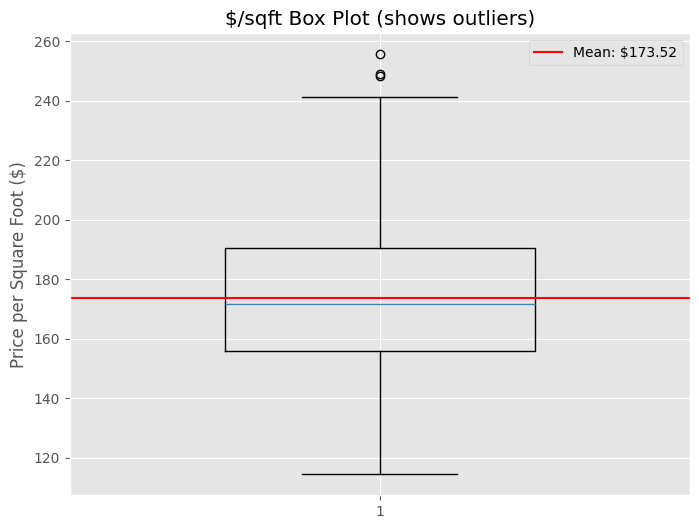

In [ ]:
#Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(df['price_per_sqft'], bins=20,  alpha=0.6)
plt.axvline(mean_psf, color='red', label=f'Mean: ${mean_psf:.2f}')


plt.xlabel('Price per Square Foot ($)', )
plt.ylabel('Number of Homes', )
plt.title('Distribution of $/sqft in Eastville')
plt.legend()
plt.show()

#Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df['price_per_sqft'], widths=0.5)
plt.axhline(mean_psf, color='red', label=f'Mean: ${mean_psf:.2f}')
plt.ylabel('Price per Square Foot ($)', )
plt.title('$/sqft Box Plot (shows outliers)')
plt.legend()
plt.show()


 CORRELATION COEFFICIENT:
   r = 0.772

 INTERPRETING CORRELATION:
   Strength: STRONG positive relationship
   Direction: As square footage increases, price tends to increase


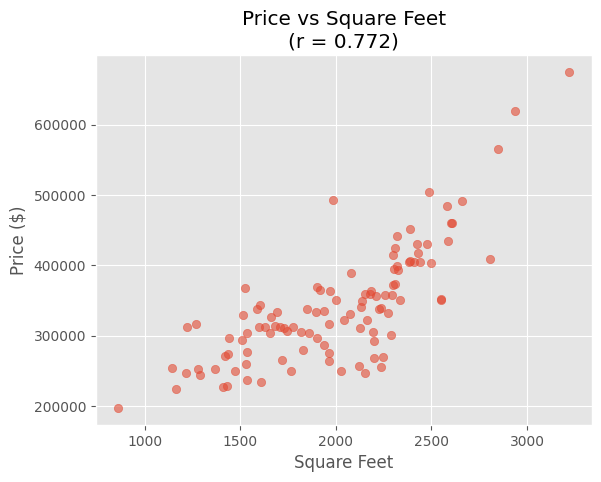

In [ ]:
#Calculate correlation coefficient
correlation_r = df['sqft'].corr(df['price'])

print(f"\n CORRELATION COEFFICIENT:")
print(f"   r = {correlation_r:.3f}")

print(f"\n INTERPRETING CORRELATION:")
if abs(correlation_r) < 0.3:
    strength = "WEAK"
elif abs(correlation_r) < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"

print(f"   Strength: {strength} {'positive' if correlation_r > 0 else 'negative'} relationship")
print(f"   Direction: As square footage increases, price tends to {'increase' if correlation_r > 0 else 'decrease'}")

#Visualize the correlation using scatterplot
plt.scatter(df['sqft'], df['price'], alpha=0.6)
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title(f'Price vs Square Feet\n(r = {correlation_r:.3f})')
plt.show()

**Conclusion**: There is a strong positive correlation between home price and square footage (r = 0.772). As the size of a house increases, its price also tends to rise, indicating that larger homes command higher market values.